In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')

In [11]:
df = pd.read_csv(r'C:\Users\DELL\Downloads\seattle-weather.csv')
print('Dimensions :', df.shape)
display(df.head())
df.info()

Dimensions : (1461, 6)


,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


<class 'pandas.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   str    
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   str    
dtypes: float64(4), str(2)
memory usage: 68.6 KB


In [12]:
display(df.describe(include='all'))
print('\nValeurs manquantes :')
print(df.isna().sum())
print('\nDistribution de la cible weather :')
print(df['weather'].value_counts())

,date,precipitation,temp_max,temp_min,wind,weather
count,1461,1461.000000,1461.000000,1461.000000,1461.000000,1461
unique,1461,NaN,NaN,NaN,NaN,5
top,2012-01-01,NaN,NaN,NaN,NaN,rain
freq,1,NaN,NaN,NaN,NaN,641
mean,NaN,3.029432,16.439083,8.234771,3.241136,NaN
std,NaN,6.680194,7.349758,5.023004,1.437825,NaN
min,NaN,0.000000,-1.600000,-7.100000,0.400000,NaN
25%,NaN,0.000000,10.600000,4.400000,2.200000,NaN
50%,NaN,0.000000,15.600000,8.300000,3.000000,NaN
75%,NaN,2.800000,22.200000,12.200000,4.000000,NaN



Valeurs manquantes :
date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

Distribution de la cible weather :
weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64


,precipitation,temp_max,temp_min,wind,weather
precipitation,1.000000,-0.228555,-0.072684,0.328045,-0.267388
temp_max,-0.228555,1.000000,0.875687,-0.164857,0.322337
temp_min,-0.072684,0.875687,1.000000,-0.074185,0.154981
wind,0.328045,-0.164857,-0.074185,1.000000,-0.065858
weather,-0.267388,0.322337,0.154981,-0.065858,1.000000


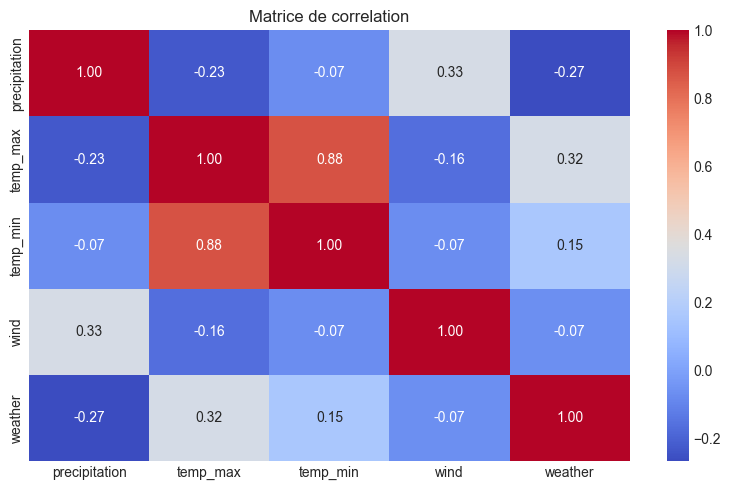

In [13]:
corr_df = df.drop(columns=['date']).copy()
corr_df['weather'] = LabelEncoder().fit_transform(corr_df['weather'])
corr_matrix = corr_df.corr(numeric_only=True)
display(corr_matrix)

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de correlation')
plt.tight_layout()
plt.show()

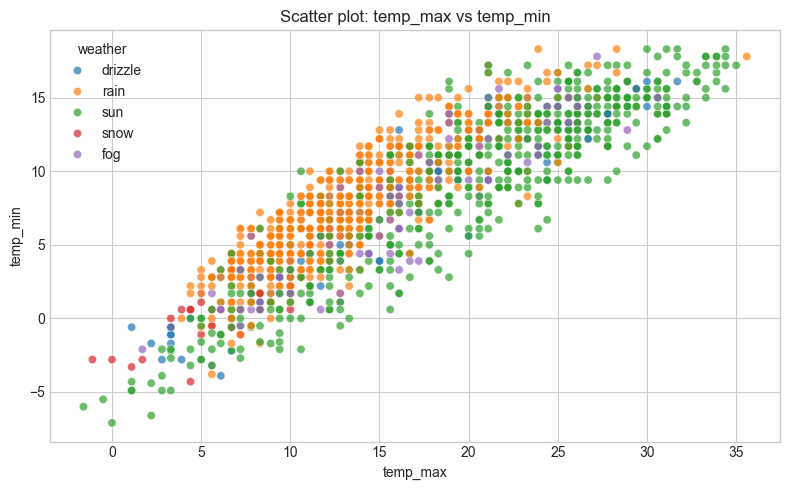

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='temp_max', y='temp_min', hue='weather', alpha=0.7)
plt.title('Scatter plot: temp_max vs temp_min')
plt.tight_layout()
plt.show()

In [15]:
df_model = df.copy()
df_model['date'] = pd.to_datetime(df_model['date'])
df_model['month'] = df_model['date'].dt.month
df_model['dayofyear'] = df_model['date'].dt.dayofyear

X = df_model.drop(columns=['weather', 'date'])
y = df_model['weather']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print('Classes :', dict(zip(le.classes_, le.transform(le.classes_))))
display(X.head())

Classes : {'drizzle': np.int64(0), 'fog': np.int64(1), 'rain': np.int64(2), 'snow': np.int64(3), 'sun': np.int64(4)}


,precipitation,temp_max,temp_min,wind,month,dayofyear
0,0.0,12.8,5.0,4.7,1,1
1,10.9,10.6,2.8,4.5,1,2
2,0.8,11.7,7.2,2.3,1,3
3,20.3,12.2,5.6,4.7,1,4
4,1.3,8.9,2.8,6.1,1,5


In [16]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print('Train :', X_train.shape, 'Test :', X_test.shape)

Train : (1168, 6) Test : (293, 6)


Best params KNN : {'knn__metric': 'manhattan', 'knn__n_neighbors': 9, 'knn__weights': 'distance'}
Accuracy KNN : 0.744

               precision    recall  f1-score   support

     drizzle       0.25      0.09      0.13        11
         fog       0.71      0.25      0.37        20
        rain       0.85      0.78      0.81       129
        snow       0.00      0.00      0.00         5
         sun       0.68      0.88      0.77       128

    accuracy                           0.74       293
   macro avg       0.50      0.40      0.42       293
weighted avg       0.73      0.74      0.72       293



C:\Users\DELL\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


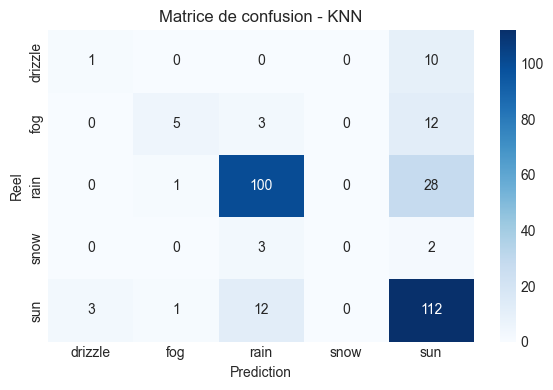

In [17]:
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_params = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

knn_search = GridSearchCV(knn_pipe, knn_params, cv=5, scoring='accuracy', n_jobs=-1)
knn_search.fit(X_train, y_train)
best_knn = knn_search.best_estimator_
y_pred_knn = best_knn.predict(X_test)

print('Best params KNN :', knn_search.best_params_)
print('Accuracy KNN :', round(accuracy_score(y_test, y_pred_knn), 4))
print('\n', classification_report(y_test, y_pred_knn, target_names=le.classes_))

cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matrice de confusion - KNN')
plt.xlabel('Prediction')
plt.ylabel('Reel')
plt.tight_layout()
plt.show()

Best params Arbre : {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Accuracy Arbre : 0.8259

               precision    recall  f1-score   support

     drizzle       1.00      0.09      0.17        11
         fog       0.00      0.00      0.00        20
        rain       0.95      0.91      0.93       129
        snow       1.00      0.40      0.57         5
         sun       0.74      0.95      0.84       128

    accuracy                           0.83       293
   macro avg       0.74      0.47      0.50       293
weighted avg       0.80      0.83      0.79       293



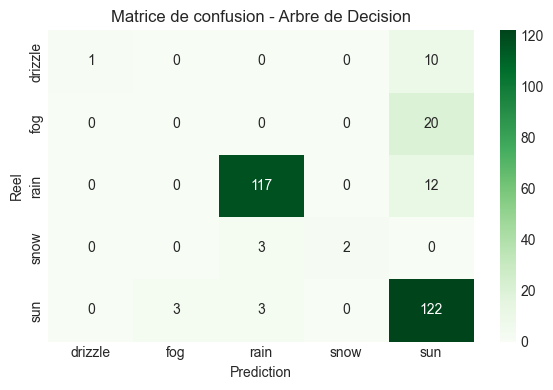

In [18]:
tree = DecisionTreeClassifier(random_state=42)
tree_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

tree_search = GridSearchCV(tree, tree_params, cv=5, scoring='accuracy', n_jobs=-1)
tree_search.fit(X_train, y_train)
best_tree = tree_search.best_estimator_
y_pred_tree = best_tree.predict(X_test)

print('Best params Arbre :', tree_search.best_params_)
print('Accuracy Arbre :', round(accuracy_score(y_test, y_pred_tree), 4))
print('\n', classification_report(y_test, y_pred_tree, target_names=le.classes_))

cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matrice de confusion - Arbre de Decision')
plt.xlabel('Prediction')
plt.ylabel('Reel')
plt.tight_layout()
plt.show()

In [19]:
results = pd.DataFrame({
    'Modele': ['KNN', 'Arbre de Decision'],
    'Accuracy': [accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_tree)]
})
display(results)
print('Meilleur modele :', results.sort_values('Accuracy', ascending=False).iloc[0]['Modele'])

,Modele,Accuracy
0,KNN,0.744027
1,Arbre de Decision,0.825939


Meilleur modele : Arbre de Decision
